# Dependency imports

In [ ]:
import torch
from torchvision.models import swin_b, Swin_B_Weights

from Training.library import validate, composeRegularTransforms, UnnormalizeImage
from Training.training import Config, TrainingResources, initClassifierTrainers, trainingLoop, GradCam
import Training.metrics as m
import Training.plotting as plots
from Training.consts import DS_PATH

# Swin-Transformer-B specific configuration

In [2]:
c = Config("Swin-B")

#Configure execution to needs
c.purge    = False  #Nincs nyúlka!

c.loadBest = True  #Utoljára tanított/legjobb betöltése

#Hiperparaméterek
c.learningRate = 8e-6
c.weightDecay  = 5e-2

#c.numClasses = 8
c.batchSize = 8
c.workers = 8


# Initialize resources

In [3]:
device = "cpu"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using {device} device")

model = swin_b(weights=Swin_B_Weights)
model.head = torch.nn.Linear(model.head.in_features, c.numClasses)

TR = TrainingResources(c, model, initClassifierTrainers, device)
TR.load(c)

print(TR.criterion)
print(TR.optimizer)

#Note: After this point only some config changes will apply

Using cuda device


/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Swin_B_Weights.IMAGENET1K_V1`. You can also use `weights=Swin_B_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loaded state
CrossEntropyLoss()
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 8e-06
    maximize: False
    weight_decay: 0.05
)


# Execute training

In [4]:
# Override training related config if neccesary
c.training = False
c.gpuSleep = 60
c.trainingEpochs = 30

trainingLoop(c, TR, stopAt=0)

Training turned off


In [5]:
display(TR.history)

,epoch,train_loss,train_acc,val_loss,val_acc,cm_true_Actinic keratoses_pred_Actinic keratoses,cm_true_Basal cell carcinoma_pred_Actinic keratoses,cm_true_Benign keratosis-like lesions_pred_Actinic keratoses,cm_true_Dermatofibroma_pred_Actinic keratoses,cm_true_Melanocytic nevi_pred_Actinic keratoses,cm_true_Melanoma_pred_Actinic keratoses,cm_true_Squamous cell carcinoma_pred_Actinic keratoses,cm_true_Vascular lesions_pred_Actinic keratoses,cm_true_Actinic keratoses_pred_Basal cell carcinoma,cm_true_Basal cell carcinoma_pred_Basal cell carcinoma,cm_true_Benign keratosis-like lesions_pred_Basal cell carcinoma,cm_true_Dermatofibroma_pred_Basal cell carcinoma,cm_true_Melanocytic nevi_pred_Basal cell carcinoma,cm_true_Melanoma_pred_Basal cell carcinoma,cm_true_Squamous cell carcinoma_pred_Basal cell carcinoma,cm_true_Vascular lesions_pred_Basal cell carcinoma,cm_true_Actinic keratoses_pred_Benign keratosis-like lesions,cm_true_Basal cell carcinoma_pred_Benign keratosis-like lesions,cm_true_Benign keratosis-like lesions_pred_Benign keratosis-like lesions,cm_true_Dermatofibroma_pred_Benign keratosis-like lesions,cm_true_Melanocytic nevi_pred_Benign keratosis-like lesions,cm_true_Melanoma_pred_Benign keratosis-like lesions,cm_true_Squamous cell carcinoma_pred_Benign keratosis-like lesions,cm_true_Vascular lesions_pred_Benign keratosis-like lesions,cm_true_Actinic keratoses_pred_Dermatofibroma,cm_true_Basal cell carcinoma_pred_Dermatofibroma,cm_true_Benign keratosis-like lesions_pred_Dermatofibroma,cm_true_Dermatofibroma_pred_Dermatofibroma,cm_true_Melanocytic nevi_pred_Dermatofibroma,cm_true_Melanoma_pred_Dermatofibroma,cm_true_Squamous cell carcinoma_pred_Dermatofibroma,cm_true_Vascular lesions_pred_Dermatofibroma,cm_true_Actinic keratoses_pred_Melanocytic nevi,cm_true_Basal cell carcinoma_pred_Melanocytic nevi,cm_true_Benign keratosis-like lesions_pred_Melanocytic nevi,cm_true_Dermatofibroma_pred_Melanocytic nevi,cm_true_Melanocytic nevi_pred_Melanocytic nevi,cm_true_Melanoma_pred_Melanocytic nevi,cm_true_Squamous cell carcinoma_pred_Melanocytic nevi,cm_true_Vascular lesions_pred_Melanocytic nevi,cm_true_Actinic keratoses_pred_Melanoma,cm_true_Basal cell carcinoma_pred_Melanoma,cm_true_Benign keratosis-like lesions_pred_Melanoma,cm_true_Dermatofibroma_pred_Melanoma,cm_true_Melanocytic nevi_pred_Melanoma,cm_true_Melanoma_pred_Melanoma,cm_true_Squamous cell carcinoma_pred_Melanoma,cm_true_Vascular lesions_pred_Melanoma,cm_true_Actinic keratoses_pred_Squamous cell carcinoma,cm_true_Basal cell carcinoma_pred_Squamous cell carcinoma,cm_true_Benign keratosis-like lesions_pred_Squamous cell carcinoma,cm_true_Dermatofibroma_pred_Squamous cell carcinoma,cm_true_Melanocytic nevi_pred_Squamous cell carcinoma,cm_true_Melanoma_pred_Squamous cell carcinoma,cm_true_Squamous cell carcinoma_pred_Squamous cell carcinoma,cm_true_Vascular lesions_pred_Squamous cell carcinoma,cm_true_Actinic keratoses_pred_Vascular lesions,cm_true_Basal cell carcinoma_pred_Vascular lesions,cm_true_Benign keratosis-like lesions_pred_Vascular lesions,cm_true_Dermatofibroma_pred_Vascular lesions,cm_true_Melanocytic nevi_pred_Vascular lesions,cm_true_Melanoma_pred_Vascular lesions,cm_true_Squamous cell carcinoma_pred_Vascular lesions,cm_true_Vascular lesions_pred_Vascular lesions
0,1,1.371299,0.599595,0.916623,0.664690,32,9,9,0,2,10,3,0,23,272,24,2,76,44,22,2,13,12,174,2,139,59,7,0,1,1,3,13,13,4,1,0,0,2,12,0,888,68,0,0,2,3,28,1,151,254,4,0,15,28,10,4,2,10,25,0,0,5,2,1,16,3,0,23
1,2,0.982860,0.680634,0.784904,0.711744,36,12,18,1,5,11,4,0,19,272,13,0,47,34,16,0,15,9,185,0,100,50,4,0,0,1,3,19,22,3,0,0,0,1,12,0,962,73,0,0,2,3,17,1,118,265,2,0,14,23,12,1,7,14,36,0,0,11,2,1,26,2,0,25
2,3,0.852909,0.715921,0.608292,0.788059,61,20,16,1,7,6,4,0,7,262,10,0,24,13,11,0,6,11,186,0,54,31,7,0,1,1,0,20,4,1,2,0,2,10,18,0,1114,102,0,0,2,10,24,1,80,294,7,0,7,15,7,1,2,5,31,0,0,3,1,0,2,0,0,25
3,4,0.753674,0.747212,0.690798,0.741795,63,18,20,1,7,12,5,0,10,274,7,0,28,14,12,0,4,6,179,0,56,23,5,0,0

# Plots of learning process

Bestval at epoch: 28


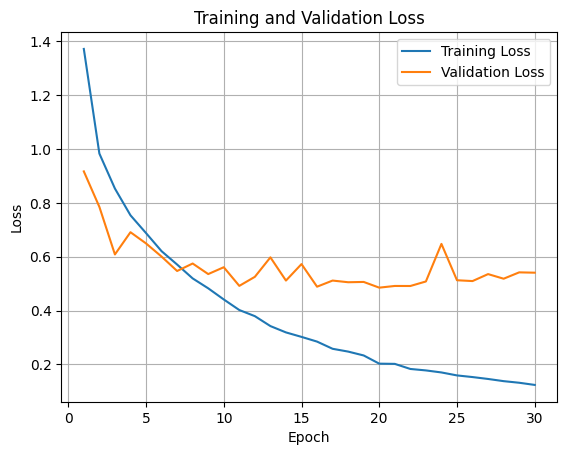

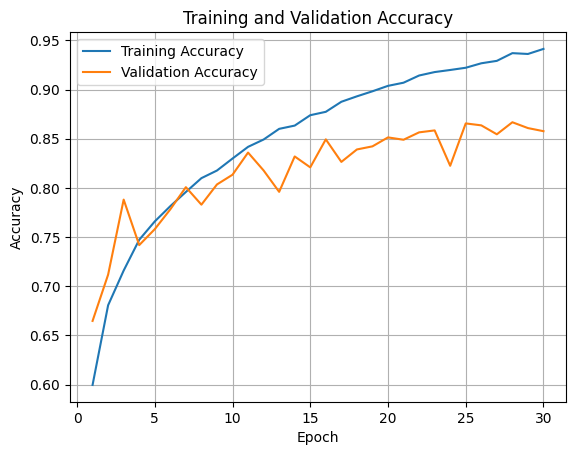

In [6]:
value = TR.history.loc[TR.history["val_acc"].idxmax(), "epoch"]
print(f"Bestval at epoch: {value}")

plots.plotTraining(TR.history, TR.plotsFolder)

# Metrics of best model on test data

### Evaluate on test set

In [7]:
#Reload weights with best validation
c.loadBest = True
TR.load(c)

#Evaluate on test set
test_loss, test_acc, CM = validate(TR.model, TR.test_loader, TR.criterion, device)

print(f"Test loss: {test_loss} \t | Test acc: {test_acc}")

Loaded state
Test loss: 0.5202819436940036 	 | Test acc: 0.8594488188976378


### Plots of test results

,accuracy,precision,recall,f1
Actinic keratoses,98.54,84.00,71.59,77.30
Basal cell carcinoma,97.52,87.71,94.29,90.88
Benign keratosis-like lesions,95.04,74.55,79.09,76.75
Dermatofibroma,99.65,86.36,76.00,80.85
Melanocytic nevi,90.59,91.53,89.75,90.63
Melanoma,91.69,76.89,76.38,76.63
Squamous cell carcinoma,99.09,82.54,81.25,81.89
Vascular lesions,99.76,83.33,96.15,89.29


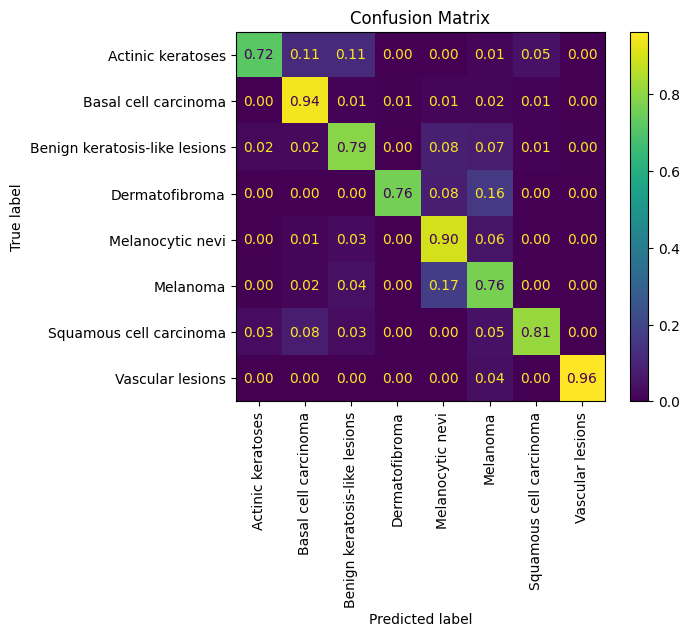

,Actinic keratoses,Basal cell carcinoma,Benign keratosis-like lesions,Dermatofibroma,Melanocytic nevi,Melanoma,Squamous cell carcinoma,Vascular lesions
Actinic keratoses,63,1,5,0,2,2,2,0
Basal cell carcinoma,10,314,6,0,16,7,5,0
Benign keratosis-like lesions,10,3,208,0,37,19,2,0
Dermatofibroma,0,2,0,19,1,0,0,0
Melanocytic nevi,0,4,22,2,1156,79,0,0
Melanoma,1,5,19,4,71,346,3,1
Squamous cell carcinoma,4,3,2,0,2,0,52,0
Vascular lesions,0,1,1,0,3,0,0,25


In [8]:
metrics = plots.deriveMetrics(CM, TR.plotsFolder)
display(metrics)
plots.plotConfusionMatrix(CM, TR.plotsFolder)
display(CM)

Best Melanoma validation @ epoch 29.0


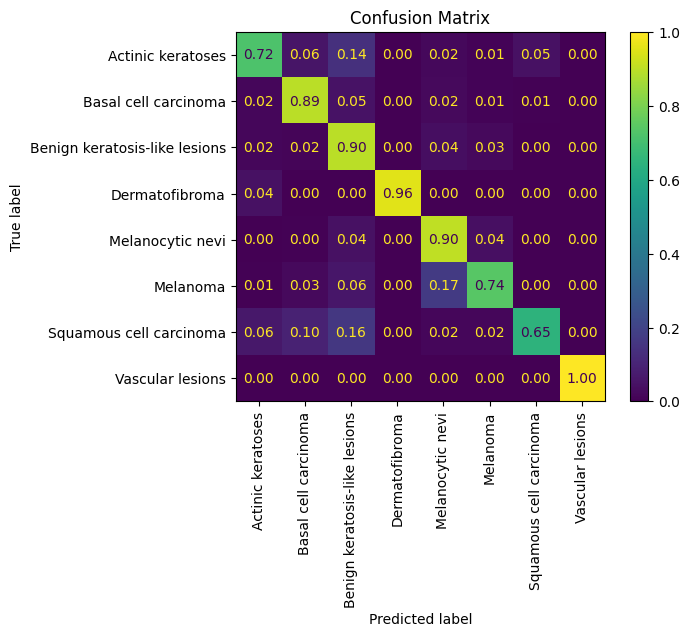

accuracy     92.80
precision    83.92
recall       73.89
f1           78.59
Name: Melanoma, dtype: float64

In [9]:
score = plots.bestMelanoma(TR)
display(score)

# Gradcam Inspection

### Prequisites for gradcam

In [ ]:
#Random melanoma input image
from PIL import Image
from random import sample
import os
from Training.training import reshape_transform_Swin

numSamples = 5

melanomaTestImagesPath = f"{DS_PATH}/test/Melanoma/"

transforms = composeRegularTransforms()

layersOfInterest = {
    "stage 1": model.features[1][-1].norm2,
    "stage 2": model.features[3][-1].norm2,
    "stage 3": model.features[5][-1].norm2,
    "stage 4": model.features[7][-1].norm2,
}

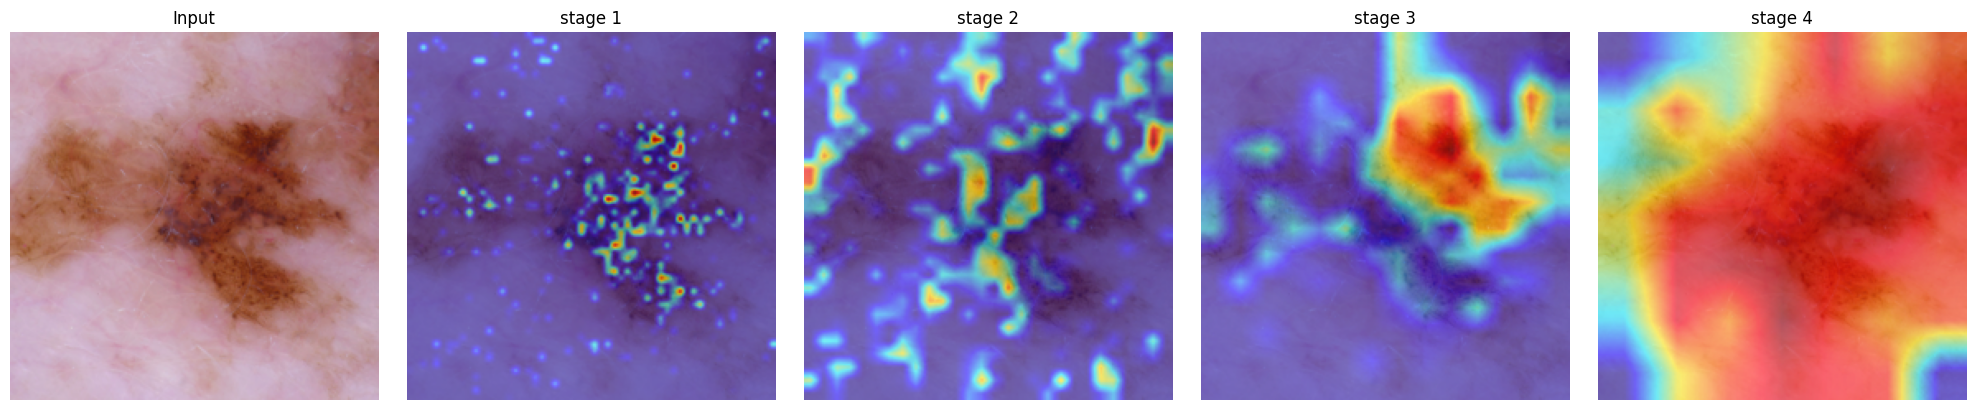

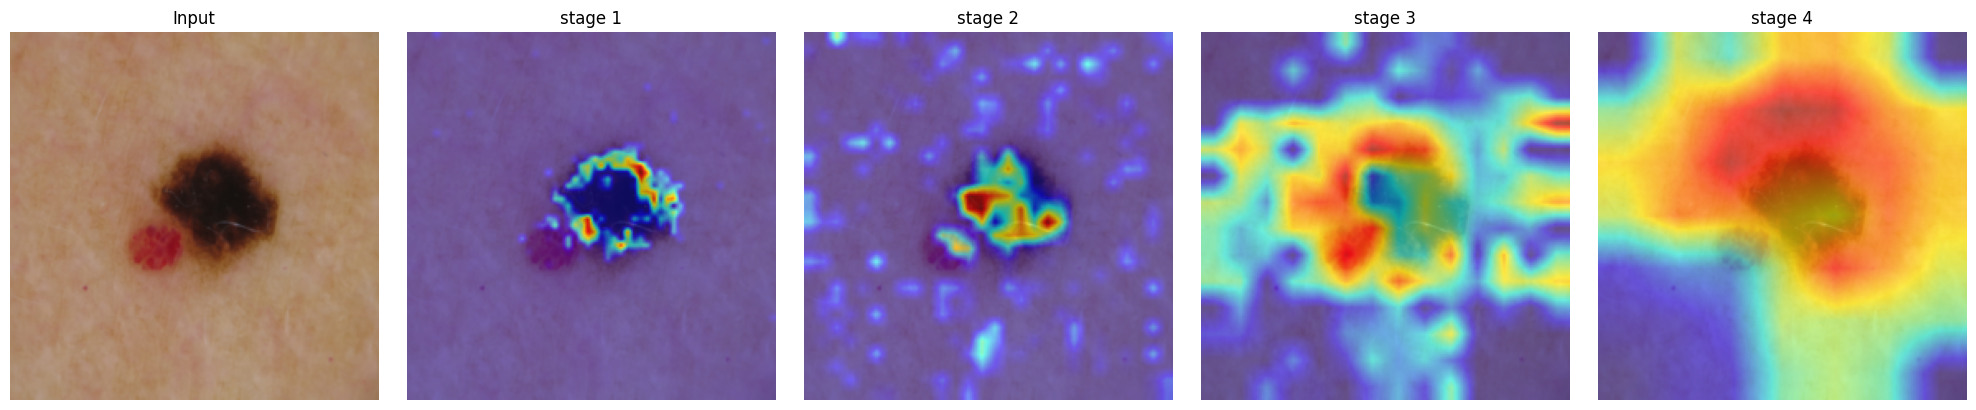

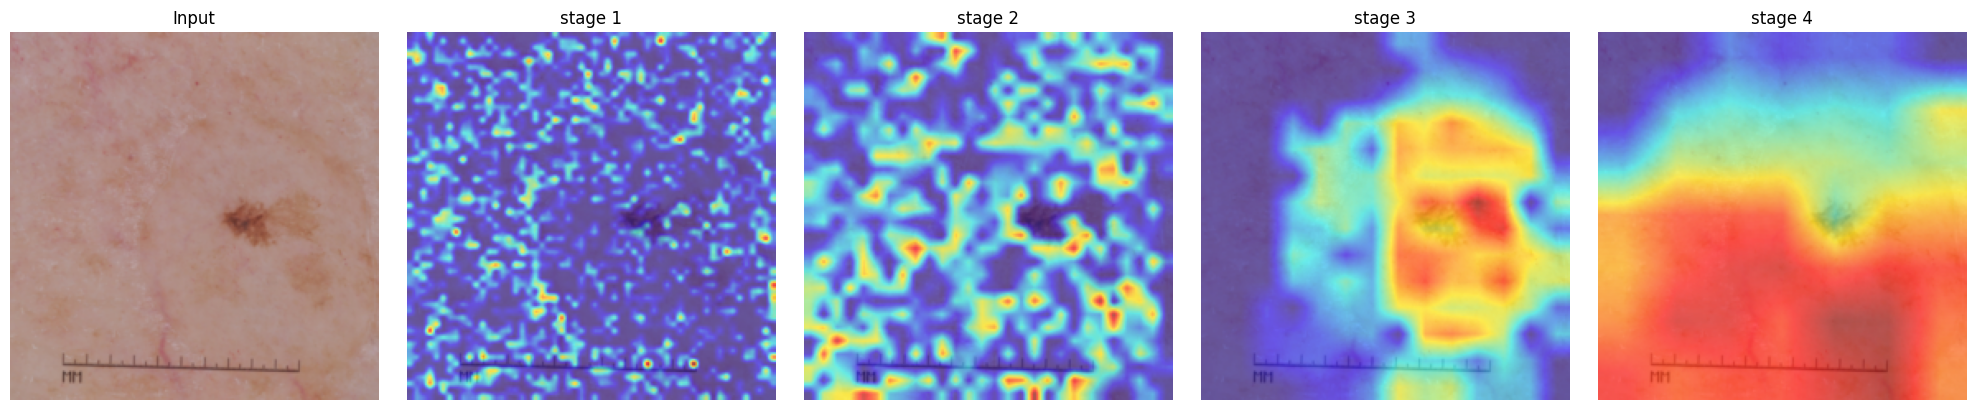

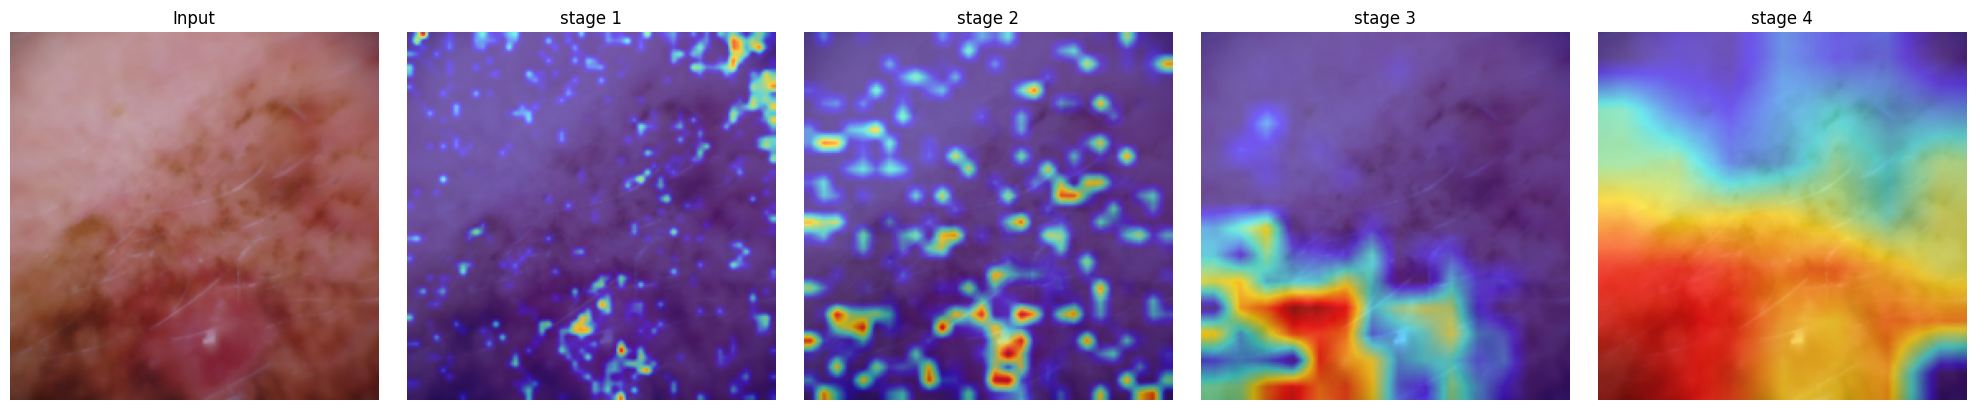

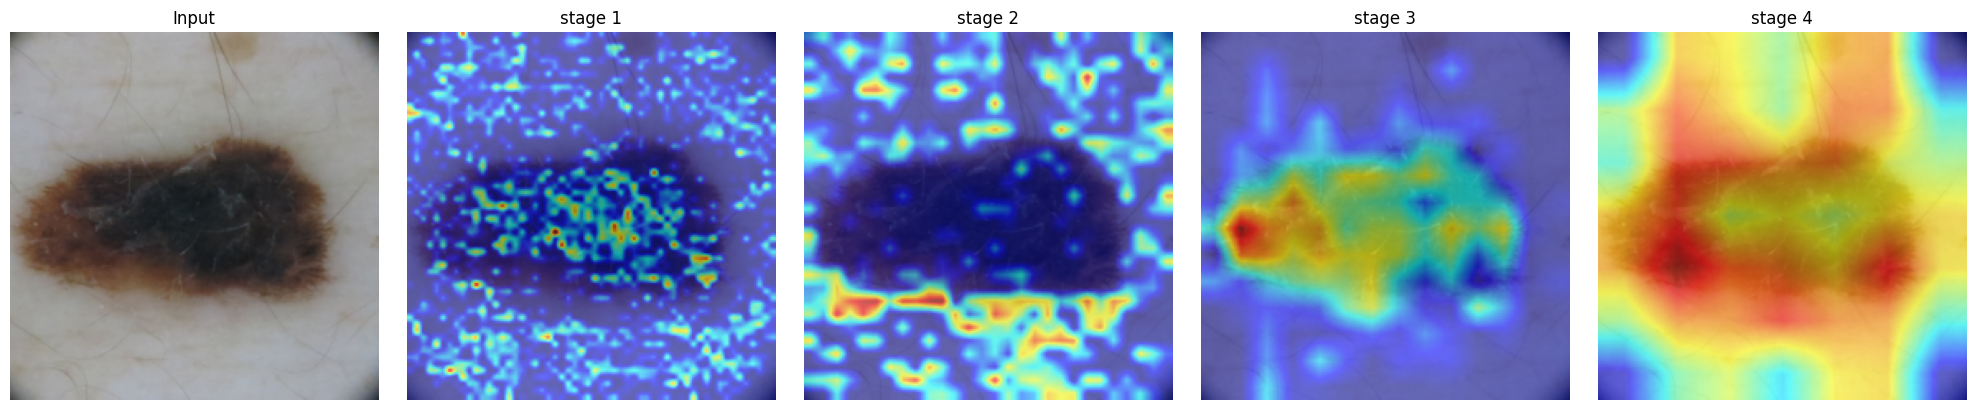

In [ ]:
imgPaths = [ melanomaTestImagesPath+img for img in sample(os.listdir(melanomaTestImagesPath), numSamples) ]

i = 0
for ip in imgPaths:
    pilImage = Image.open(ip).convert("RGB")
    inputTensor = transforms(pilImage)
    rgbImage = UnnormalizeImage(inputTensor)

    vis = GradCam(TR, inputTensor, layersOfInterest, reshape_transform_Swin, rgbImage )

    plots.plotGradCam(rgbImage, vis, TR.gradCamsFolder + f"/gc_{i}")
    i += 1
